## 0. Load Modules and Setup Model

In [1]:
import torch
from diffusers import StableDiffusionInpaintPipeline
from diffusers.utils import load_image

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

c:\Users\teng0\anaconda3\envs\ece285\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\teng0\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\teng0\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aed

## 1. Visualization Before Processing

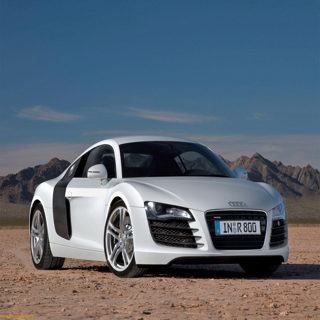

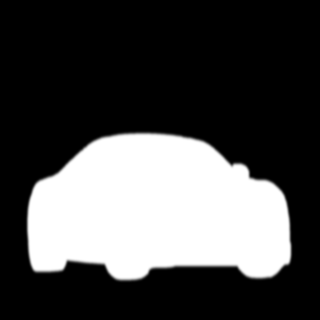

In [54]:
from PIL import Image
from PIL import ImageOps
from PIL import ImageDraw
from io import BytesIO
import numpy as np

# size of images
S = 320

init_image = load_image(r"D:\UCSD_courses\ECE285\project\data\cleaned\train\images\001192_jpg.rf.954b9392e38bbd485498d3e872cd5e6a.jpg")
mask_image = load_image(r"D:\UCSD_courses\ECE285\project\data\cleaned\train\masks\001192_jpg.rf.954b9392e38bbd485498d3e872cd5e6a.png")
W, H = init_image.size
width = round(W/64)*64
height = round(H/64)*64

# Display the original image and the mask
display(init_image.resize((S, S)))
display(mask_image.resize((S, S)))

In [90]:
def pad_image_to_square(img: Image, mode="reflect"):
    W, H = img.size
    S = max(W, H)
    pad_x = (S - W) // 2
    pad_y = (S - H) // 2

    if mode == "reflect":
        padded = ImageOps.expand(
            img,
            border=(pad_x, pad_y, S - W - pad_x, S - H - pad_y),
            fill=None
        )
    else:
        padded = Image.new(img.mode, (S, S), (114, 114, 114))
        padded.paste(img, (pad_x, pad_y))

    return padded, pad_x, pad_y

In [91]:
def generate_pad_bbox(bbox:list, pad_x, pad_y, S):
    """
    Take in a list of bbox coordinates, example:
    "bbox": [73,296,908,302]
    and generate new coordinates in YOLO format
    """
    x, y, w, h = bbox  # COCO: x,y,width,height
    
    x1, y1 = x + pad_x, y + pad_y
    x2, y2 = x + w + pad_x, y + h + pad_y

    cx = ((x1 + x2) / 2.0) / S
    cy = ((y1 + y2) / 2.0) / S
    bw = w / S
    bh = h / S

    return cx, cy, bw, bh

In [93]:
from pathlib import Path

def save_yolo_label(fpath:Path, coords:list, cls_id: int = 0):
    """
    params:
        fname:Path,  path of the file to be saved
        coords:list, 4 elements in format -> cx, cy, bw, bh
    """
    if len(coords) != 4:
        raise ValueError("coords must be [cx, cy, bw, bh]")

    cx, cy, bw, bh = map(float, coords)

    # clamp to [0, 1] (safety)
    cx = min(max(cx, 0.0), 1.0)
    cy = min(max(cy, 0.0), 1.0)
    bw = min(max(bw, 0.0), 1.0)
    bh = min(max(bh, 0.0), 1.0)

    out_path = fpath
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # YOLO format: class cx cy w h
    out_path.write_text(f"{int(cls_id)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

Pad_x: 0
Pad_y: 200


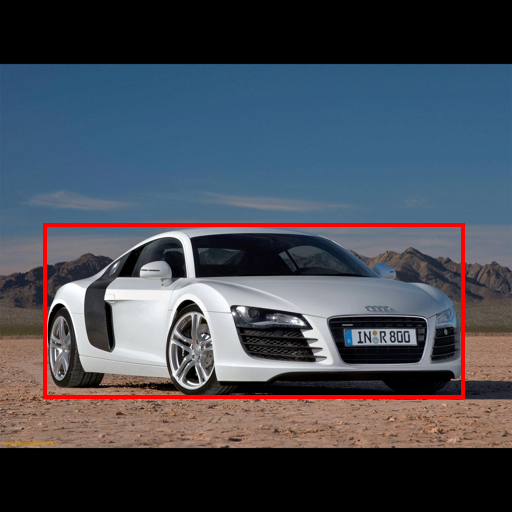

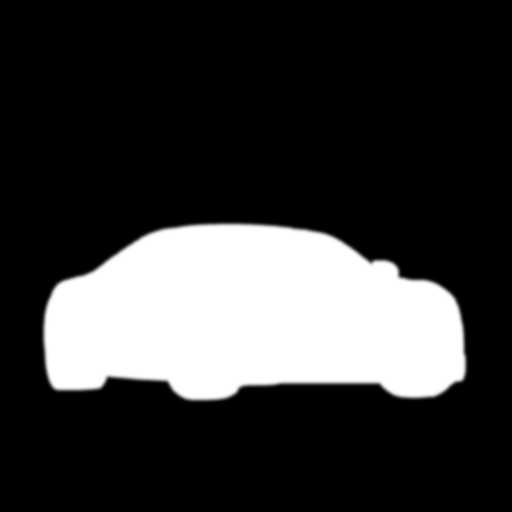

In [ ]:
OUT_DIR = Path(r"D:\UCSD_courses\ECE285\project\generated\train")


# Small test and check bounding box by displaying images
pad_img, pad_x, pad_y = pad_image_to_square(init_image)
pad_mask, *_ = pad_image_to_square(mask_image)
s = pad_img.size[0]

original_coords = [136,499,1314,546]
print(f"Pad_x: {pad_x}")
print(f"Pad_y: {pad_y}")
cx, cy, w, h = generate_pad_bbox(original_coords, pad_x, pad_y, s)

coords = [cx, cy, w, h]
test_f = "labels\\001_v1.jpg"

fname = test_f.strip(".jpg") + ".txt"
save_yolo_label(OUT_DIR + fname, coords)


resize_img = pad_img.resize((512, 512))
resize_msk = pad_mask.resize((512, 512))
new_s = resize_img.size[0]

# display pad_img and pad_coords togather
# Convert YOLO normalized back to pixel coords for visualization
x1 = (cx - w/2) * new_s
y1 = (cy - h/2) * new_s
x2 = (cx + w/2) * new_s
y2 = (cy + h/2) * new_s

# x1 = original_coords[0] + pad_x
# x2 = x1 + original_coords[2]
# y1 = original_coords[1] + pad_y
# y2 = y1 + original_coords[3]


# Draw bounding box
draw_img = resize_img.copy()
draw = ImageDraw.Draw(draw_img)
draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

display(draw_img)
display(resize_msk)

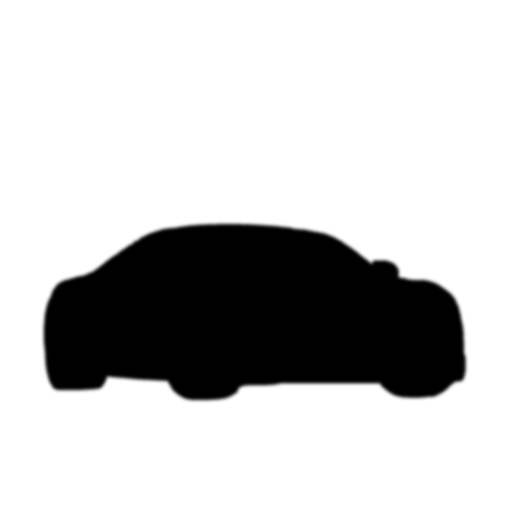

In [78]:
# Invert the mask image
inverted_mask = ImageOps.invert(pad_mask)

# Display the inverted mask
display(inverted_mask.resize((512, 512)))

100%|██████████| 50/50 [00:03<00:00, 12.90it/s]


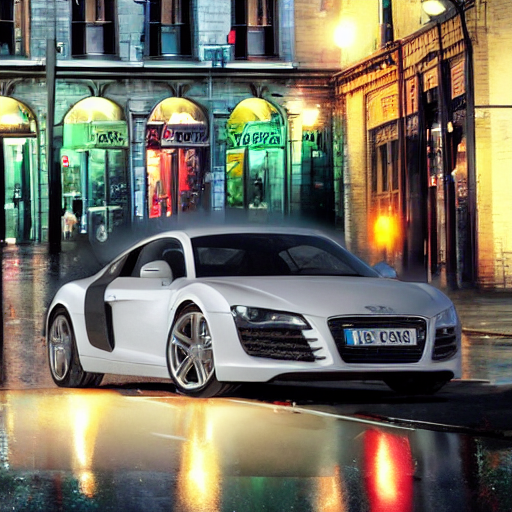

In [ ]:
prompt = "An raining urban street"

# Perform inpainting using the inverted mask
image_outside_mask = pipe(prompt=prompt, image=pad_img, mask_image=inverted_mask).images[0]

# Display the inpainted image (outside the original mask)
display(image_outside_mask.resize((512, 512), Image.BICUBIC))

## 2. Generate Variants for Each Image

In [89]:
import json

# 0. Define the path
IN_DIR = Path(r"D:\UCSD_courses\ECE285\project\data\cleaned\train")
BASE_DIR = Path(r"D:\UCSD_courses\ECE285\project\generated\train")
# Input
IMG_IN_DIR = IN_DIR / "images"
MSK_IN_DIR = IN_DIR / "masks"
LBL_IN = Path(r"D:\UCSD_courses\ECE285\project\data\cleaned\train\labels\cleaned_index.json")
# Output
IMG_OUT_DIR = BASE_DIR / "images"
LBL_OUT_DIR = BASE_DIR / "labels"

IMG_OUT_DIR.mkdir(parents=True, exist_ok=True)
LBL_OUT_DIR.mkdir(parents=True, exist_ok=True)

### 2.1 Processing Pipeline

In [97]:
from tqdm.auto import tqdm

# 0. setup some variables
with open(LBL_IN, "r") as f:
    data = json.load(f)
bbox_lookup = {entry["file_name"]: entry["bbox"] for entry in data}

prompts = [
    "A raining urban street",
    "An urban street with snow",
    "An urban street at night"
]
image_list = [p for p in IMG_IN_DIR.iterdir()]
pipe.set_progress_bar_config(disable=True)
# 1. Iterate Through All input images
count = 1
for image in tqdm(image_list, desc="Generating"):
    init_image = load_image(str(image)).convert("RGB")
    mask_path = MSK_IN_DIR / f"{image.stem}.png"
    init_mask = load_image(str(mask_path)).convert("L")
    if count % 200 == 0:
        print(f"Processing {count}th Image")
    # 2. Pad each image and mask
    pad_image, pad_x, pad_y = pad_image_to_square(init_image)
    pad_mask, _, _ = pad_image_to_square(init_mask)
    inverted_mask = ImageOps.invert(pad_mask)
    # s the square size of padded image
    s = pad_image.size[0]

    # 3. generate new bbox
    coco_bbox = bbox_lookup[image.name]
    cx, cy, w, h = generate_pad_bbox(coco_bbox, pad_x, pad_y, s)
    coords = [cx, cy, w, h]

    # 4. generate variants of image
    for i, prompt in enumerate(prompts):
        new_image = pipe(prompt=prompt, image=pad_image, mask_image=inverted_mask).images[0]
        new_stem = f"{image.stem}_v{i}"

        img_out_path = IMG_OUT_DIR / f"{new_stem}.jpg"
        lbl_out_path = LBL_OUT_DIR / f"{new_stem}.txt"

        new_image.save(img_out_path, quality=95)
        save_yolo_label(lbl_out_path, coords, cls_id=0)


Generating:  38%|███▊      | 549/1433 [1:52:42<3:00:56, 12.28s/it]Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Generating:  42%|████▏     | 608/1433 [2:04:48<2:49:04, 12.30s/it]Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Generating:  72%|███████▏  | 1029/1433 [3:31:02<1:22:51, 12.31s/it]Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black imag

### 2.2 Post Processing

In [98]:
for img_path in IMG_OUT_DIR.iterdir():
    img = Image.open(img_path)
    # nearly pure black
    if np.mean(np.array(img)) < 1:   
        print("Removing black image:", img_path.name)
        img_path.unlink()
        (LBL_OUT_DIR / img_path.with_suffix(".txt").name).unlink(missing_ok=True)

Removing black image: 000408_jpg.rf.bad00409f32f8528beb1365a0774739f_v0.jpg
Removing black image: 001089_jpg.rf.1971e4977a28f0830dba622d0cd6e737_v1.jpg
Removing black image: 001153_jpg.rf.2210b673a4598e5109c33fa6a671166b_v2.jpg
Removing black image: 002893_jpg.rf.ebd1f6ef84bd31d515fdea7bcb6df425_v0.jpg
Removing black image: 003635_jpg.rf.8995d3c5e413a2c1c3b9686dab5af67e_v0.jpg
Removing black image: 003670_jpg.rf.c87432d862c5daa46b223fc17780d6d7_v0.jpg
Removing black image: 004592_jpg.rf.7ece042abe2c0d5ed1716b24424ee249_v0.jpg
Removing black image: 006413_jpg.rf.265813a9ae3651d84e2136205c07b4a8_v0.jpg
Removing black image: 006413_jpg.rf.265813a9ae3651d84e2136205c07b4a8_v2.jpg
Removing black image: 007498_jpg.rf.2b82ef06c81c960e07600fc81ebf031f_v0.jpg
Removing black image: 007557_jpg.rf.a7dfbc22c738281425598a4bc7ce3321_v0.jpg
Removing black image: 007572_jpg.rf.2ef41a60aa12f721a73a2c202627964e_v1.jpg
Removing black image: 007572_jpg.rf.2ef41a60aa12f721a73a2c202627964e_v2.jpg
Removing bla